# Demo of DISC tomography based on a 3D model (passive seismci data)

## Description
This notebook implements DISC based on a 3D model (passive seismic data). 
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [1]:
#####Step1 import necessary package

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
import sys
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os
from pyekfmm import ray3d2,extract
from pyseistr import plot3d



In [2]:
#####Step2 create real checkboard model

nx=41;ny=41;nz=41;  ###model size 
dx=0.2;dy=0.2;dz=0.2;      ###spacing rinterval (unit km)


# coordinates of the nodes
xx = np.arange(0, (nx)*dx, dx)
yy = np.arange(0, (ny)*dy, dy)
zz = np.arange(0, (nz)*dz, dz)

#specify the anomaly
vlow=2 #(km/s)
vhig=5 #(km/s)


v=vlow*np.ones([nx,ny,nz]); #(x,y,z)

cz=np.floor((nz+1)/2-6).astype('int');coor_cz=zz[cz];
cx=np.floor((nx+1)/2+0).astype('int');coor_cx=xx[cx];
cy=np.floor((ny+1)/2+0).astype('int');coor_cy=yy[cy];

half = 1.0  

coor_x, coor_y, coor_z = np.meshgrid(xx, yy, zz, indexing='ij')

cube = (
    (np.abs(coor_z - coor_cz) <= half) &
    (np.abs(coor_x - coor_cx) <= half) &
    (np.abs(coor_y - coor_cy) <= half)
)

v[cube] = vhig

#########geometry setting
n_sources=5;

sourcex=[2,4,3,5,6]  ###sourcex
sourcey=[2.5,4.5,3,5,6.5] ###sourcey
sourcez=[6.5,6,6.3,7,7.5] ###sourcez
sources=np.column_stack((sourcex, sourcey, sourcez))



n_receivers=25;
receiverx=[0.0,1,3,5,7]  ###receiverx
receivery=[0.0,1,3,5,7]  ###receivery
receiverz=[0.0,0.0,0.0,0.0,0.0]  ###receiverz

X, Y = np.meshgrid(receiverx, receivery, indexing='ij')
Z = np.zeros_like(X)

receivers = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))

v_true=v
v_init=vlow*np.ones_like(v_true)

In [3]:
#####Step3 build ray path matrix based on eikonal wave equation
address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

###compute traveltime for each ray based on eikonal equation
traveltimes,ray_paths=compute_travel_times3D(v_true, sources, receivers, dx, dy,dz ,nx, ny,nz, 1)  

######the output sequency of ray_paths is (ray_x,ray_y,ray_z)


###build ray path matrix 
A=build_ray_matrix3D(ray_paths, dx, dy, dz, nx, ny, nz ,1,1)


operef=A.toarray()

obst=(np.squeeze(traveltimes))  ####observed traveltime from Eikonal equation

nd=len(obst) #####length of traveltime vector


time_eik=np.squeeze(traveltimes).reshape(n_sources,n_receivers); #traveltime estimated usig eikonal equation

time_cal=A.dot(1./v_true.reshape(nx*ny*nz,1,order='F')).reshape(n_sources,n_receivers) #### traveltime calculated using ray path matrix and true velocity model


print(np.mean((time_eik-time_cal)**2))

0.02233508033923107


In [4]:
x_max = -float("inf")
y_max = -float("inf")

x_min = float("inf")
y_min = float("inf")

z_min = float("inf")
z_max = -float("inf")

for i, (ray_x, ray_y, ray_z) in enumerate(ray_paths):   #####(x,y,z)
    for x, y,z in zip(ray_x, ray_y,ray_z):
        x_max = max(x_max, x)
        y_max = max(y_max, y)

        x_min = min(x_min, x)
        y_min = min(y_min, y)

        z_min = min(z_min, z)
        z_max = max(z_max, z)

print(f"x: min={x_min}, max={x_max}")
print(f"y: min={y_min}, max={y_max}")
print(f"z: min={z_min}, max={z_max}")

x: min=0.0, max=7.0
y: min=0.0, max=7.0
z: min=0.0, max=7.632104568183422


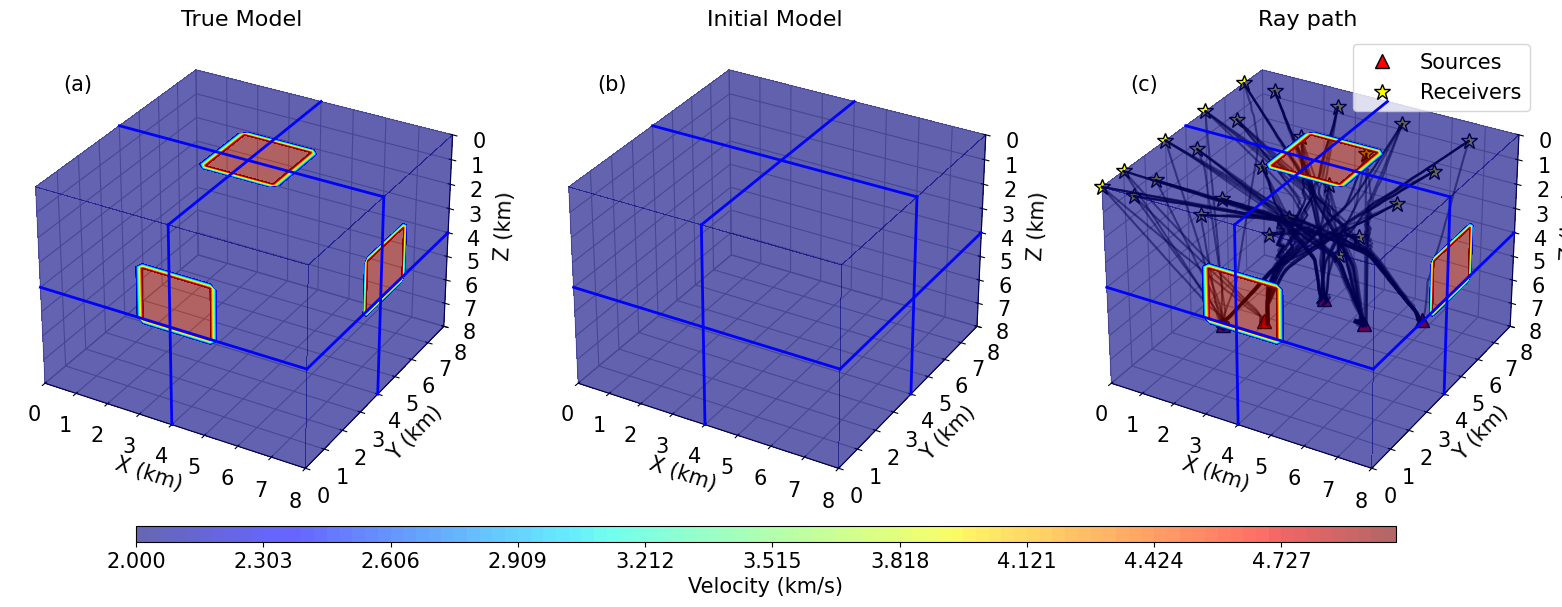

In [5]:
########Step 4 observed travel time comparison

v_low = 2
v_hig = 5


figadd=address+'/Figure/'

fig = plt.figure(figsize=(18, 8))
# --- Figure 1: v_true ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.jet,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax1.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax1.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax1.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax1.set_title("True Model", fontsize=16, fontweight='normal')
for tick in ax1.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
    
mappable = ax1.collections[0]
cax = fig.add_axes([0.12, 0.20, 0.7, 0.02])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('Velocity (km/s)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_xticklabels():  # For horizontal: get_xticklabels()
	label.set_fontweight('normal')
	label.set_fontname('DejaVu Sans')
ax1.text(1,-0,-4, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
    
# --- Figure 2: v_init ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
plot3d(np.transpose(v_init, [2,0,1]), levels=[2,2.001], x=xx, y=yy, z=zz,
       cmap=plt.cm.jet,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax2.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax2.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax2.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax2.set_title("Initial Model", fontsize=16, fontweight='normal')
for tick in ax2.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
ax2.text(1,-0,-4, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
# --- Figure 3: raypath ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.jet,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax3.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax3.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax3.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax3.set_title("Ray path", fontsize=16, fontweight='normal')
# ax3.plot(sources[:,0],sources[:,1],sources[:,2],'r^',  markersize=15)
# ax3.plot(receivers[:,0],receivers[:,1],receivers[:,2],'y*',  markersize=15)
ax3.plot(
    sources[:, 0],
    sources[:, 1],
    sources[:, 2],
    marker='^',
    linestyle='None',
    color='red',
    markeredgecolor='black',
    markersize=10,
    label='Sources'
)

ax3.plot(
    receivers[:, 0],
    receivers[:, 1],
    receivers[:, 2],
    marker='*',
    linestyle='None',
    color='yellow',
    markeredgecolor='black',
    markersize=12,
    label='Receivers'
)

ax3.legend(loc='upper right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})

for tick in ax3.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for ray_x, ray_y, ray_z in ray_paths:
    ax3.plot(ray_x, ray_y, ray_z, 'k-', alpha=0.5)

ax3.text(1,-0,-4, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')  

plt.subplots_adjust(bottom=0.21)
plt.subplots_adjust(wspace=0.15)
plt.subplots_adjust(left=0.05)
plt.show()
	

2.3724350929260254 5.0121636390686035


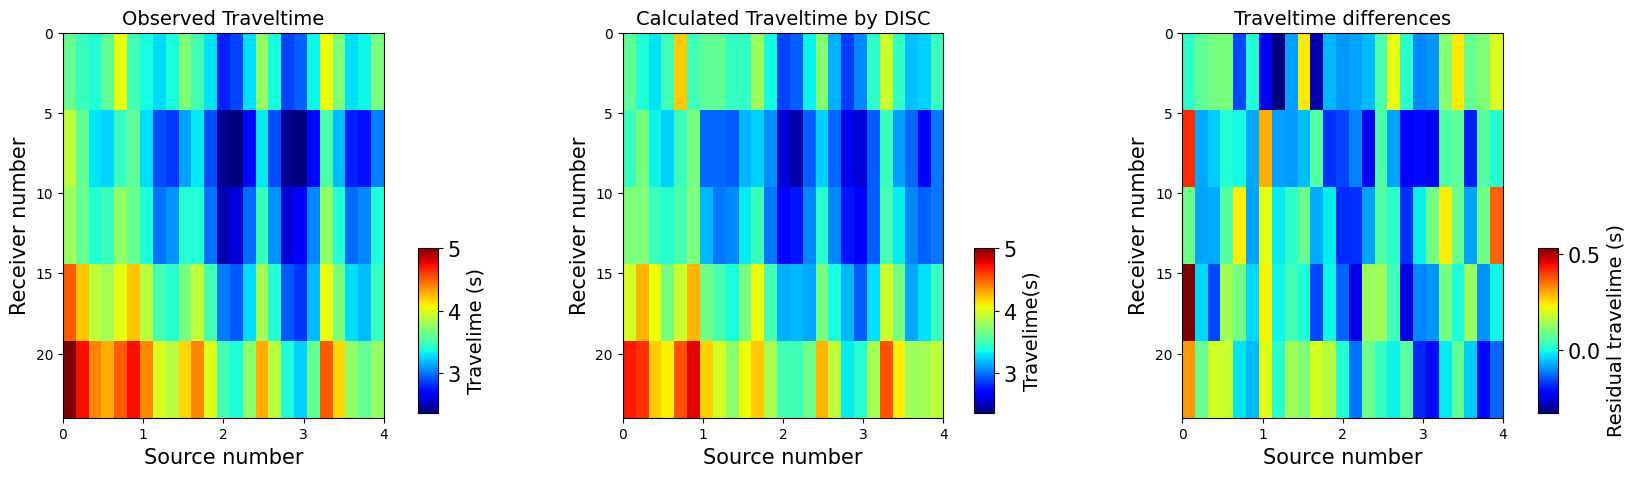

In [6]:
tlow=time_eik.min()
thig=time_eik.max()

vasp=0.2

print(time_eik.min(),time_eik.max())

fig, axes = plt.subplots(1, 3, figsize=(20,5))
for ii,ax in enumerate(axes.flatten()):
		
	if ii==0:	
		im1=ax.imshow(time_eik,cmap='jet',vmin=tlow,vmax=thig,extent=[0,(n_sources-1),(n_receivers-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		# ax.text(-8,0, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.33, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Travelime (s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.set_title('Observed Traveltime', fontsize=14)
			
			
	if ii==1:	
		im1=ax.imshow(time_cal,cmap='jet',vmin=tlow,vmax=thig,extent=[0,(n_sources-1),(n_receivers-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		# ax.text(-8,0, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.608, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Travelime(s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.set_title('Calculated Traveltime by DISC', fontsize=14)
	if ii==2:	
		im1=ax.imshow(time_eik-time_cal,cmap='jet',extent=[0,(n_sources-1),(n_receivers-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		# ax.text(-8,0, '(e)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')
		colorbar_position = [0.89, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Residual travelime (s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
			label.set_fontsize(15)
		ax.set_title('Traveltime differences', fontsize=14)
		

plt.subplots_adjust(hspace=0.25)	
plt.subplots_adjust(wspace=0.3)	

plt.show()

In [7]:
########Step 5 tomography inversion using DISC method in 3D case 
import time

oniter=8  ####number of outer iteration
initer=5   ####number of inner iteration
v_disc=vlow*np.ones_like(v_true)

t0 = time.perf_counter()
for i in range(oniter):
	_,ray_pathsini=compute_travel_times3D(v_disc, sources, receivers, dx, dy,dz, nx, ny, nz, 1)   ###ray traceing based on the given model
	opsr=build_ray_matrix3D(ray_pathsini, dx, dy, dz,nx, ny,nz,1,1)  ####build ray path matrix using the initial model
	nm=opsr.toarray().shape[1] 
	
	par_S={'nm':nm,'nd':nm,'nbox':[6,6,6],'ndat':[nx,ny,nz],'ndim':3}### shaping operator setting
	v_disc=tomoloop3D(v_disc,opsr,initer,nx,ny,nz,nd,obst,par_S) ### gradient estimation and model update

	v_disc = np.clip(v_disc, v_low, v_hig)

	print('iter=',i+1,np.linalg.norm(obst-np.matmul(opsr.toarray(),1./v_disc.flatten(order='F'))))

dtdisc = time.perf_counter() - t0
print('DISCt=',dtdisc) #estimated calculation time



iter= 1 5.668500019927245
iter= 2 5.682685749253189
iter= 3 5.581807187548251
iter= 4 2.767242391798179
iter= 5 2.184571838548651
iter= 6 1.9059560539084777
iter= 7 2.2791776862874062
iter= 8 1.8117325609035304
DISCt= 23.44464384391904


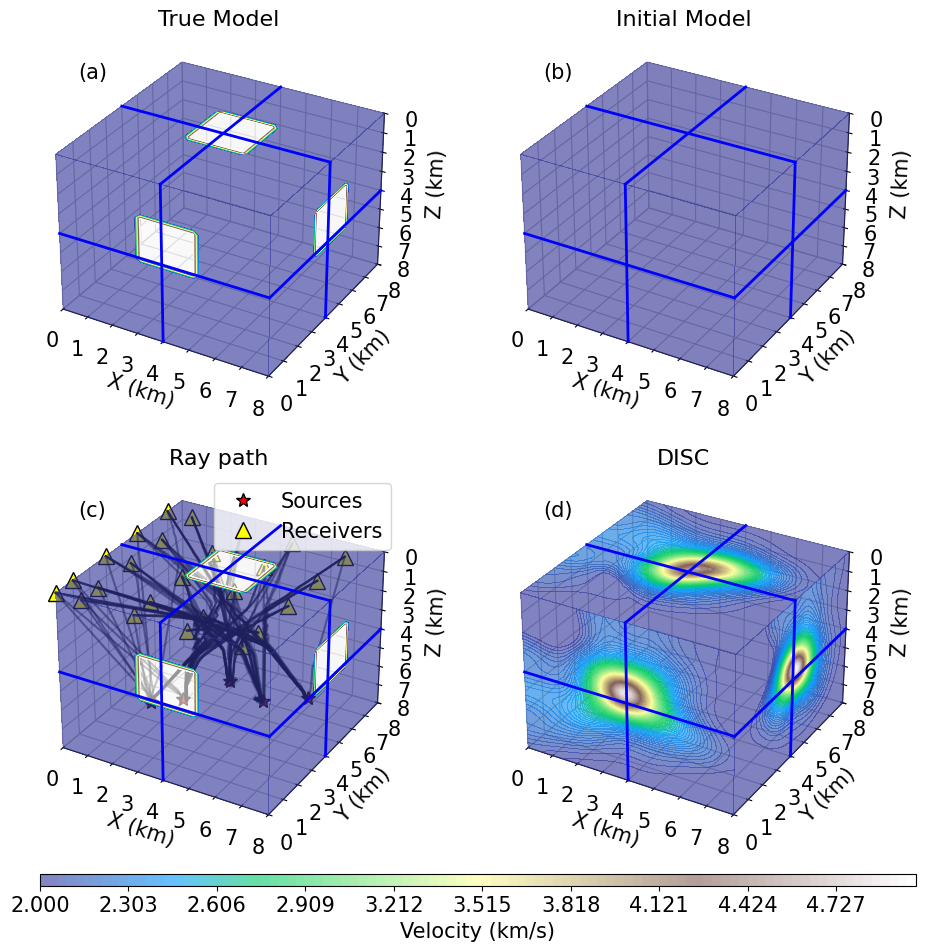

In [ ]:
fig = plt.figure(figsize=(12,12))
# --- Figure 1: v_true ---
ax1 = fig.add_subplot(2,2, 1, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax1.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax1.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax1.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax1.set_title("True Model", fontsize=16, fontweight='normal')
for tick in ax1.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax1.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
    
mappable = ax1.collections[0]
cax = fig.add_axes([0.17, 0.17, 0.73, 0.01])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('Velocity (km/s)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_xticklabels():  # For horizontal: get_xticklabels()
	label.set_fontweight('normal')
	label.set_fontname('DejaVu Sans')
ax1.text(1,-0,-4, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
    
# --- Figure 2: v_init ---
ax2 = fig.add_subplot(2,2, 2, projection='3d')
plot3d(np.transpose(v_init, [2,0,1]), levels=[2,2.001], x=xx, y=yy, z=zz,
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax2.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax2.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax2.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax2.set_title("Initial Model", fontsize=16, fontweight='normal')
for tick in ax2.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax2.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
ax2.text(1,-0,-4, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')    
# --- Figure 3: raypath ---
ax3 = fig.add_subplot(2,2, 3, projection='3d')
plot3d(np.transpose(v_true, [2,0,1]), x=xx, y=yy, z=zz,
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax3.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax3.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax3.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax3.set_title("Ray path", fontsize=16, fontweight='normal')
# ax3.plot(sources[:,0],sources[:,1],sources[:,2],'r^',  markersize=15)
# ax3.plot(receivers[:,0],receivers[:,1],receivers[:,2],'y*',  markersize=15)
ax3.plot(
    sources[:, 0],
    sources[:, 1],
    sources[:, 2],
    marker='*',
    linestyle='None',
    color='red',
    markeredgecolor='black',
    markersize=10,
    label='Sources'
)

ax3.plot(
    receivers[:, 0],
    receivers[:, 1],
    receivers[:, 2],
    marker='^',
    linestyle='None',
    color='yellow',
    markeredgecolor='black',

    markersize=12,
    label='Receivers'
)

ax3.legend(loc='upper right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})

for tick in ax3.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax3.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for ray_x, ray_y, ray_z in ray_paths:
    ax3.plot(ray_x, ray_y, ray_z, 'k-', alpha=0.5)

ax3.text(1,-0,-4, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')

# --- Figure 3: raypath ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
plot3d(np.transpose(v_disc, [2,0,1]),  x=xx, y=yy, z=zz,
       cmap=plt.cm.terrain,  alpha=0.6,
       ifnewfig=False, showf=False, close=False)
ax4.set_xlabel("X (km)", fontsize=15, fontweight='normal')
ax4.set_ylabel("Y (km)", fontsize=15, fontweight='normal')
ax4.set_zlabel("Z (km)", fontsize=15, fontweight='normal')
ax4.set_title("DISC", fontsize=16, fontweight='normal')
for tick in ax4.get_xticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
for tick in ax4.get_yticklabels():
    tick.set_fontweight('normal')
    tick.set_fontsize(15)
    tick.set_fontname('DejaVu Sans')
for tick in ax4.get_zticklabels():
    tick.set_fontweight('normal')
    tick.set_fontname('DejaVu Sans')
    tick.set_fontsize(15)
ax4.text(1,-0,-4, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')     

plt.subplots_adjust(bottom=0.21)
plt.subplots_adjust(wspace=0.)
# plt.subplots_adjust(left=-3)
# plt.savefig(figadd+"syn3dpass.png", dpi=300)	
plt.show()